2024-10-05 13:51:09 [INFO] __main__ <158570415.py:12>: SMACross started with param: {'ticker': 'USD/MSFT', 'fast': 10, 'slow': 30}
2024-10-05 13:51:09 [INFO] tradingbot.bot <bot.py:242>: Now Triggered ⌚'2024-01-01 00:00:00': SMACross({'ticker': 'USD/MSFT', 'fast': 10, 'slow': 30}) by [StrategyFirstRun(), StandardInterval('1 days 00:00:00')]
2024-10-05 13:51:09 [INFO] tradingbot.bot <bot.py:242>: Now Triggered ⌚'2024-01-02 00:00:00': SMACross({'ticker': 'USD/MSFT', 'fast': 10, 'slow': 30}) by [StandardInterval('1 days 00:00:00')]
2024-10-05 13:51:09 [INFO] tradingbot.bot <bot.py:242>: Now Triggered ⌚'2024-01-03 00:00:00': SMACross({'ticker': 'USD/MSFT', 'fast': 10, 'slow': 30}) by [StandardInterval('1 days 00:00:00')]
2024-10-05 13:51:09 [INFO] tradingbot.bot <bot.py:242>: Now Triggered ⌚'2024-01-04 00:00:00': SMACross({'ticker': 'USD/MSFT', 'fast': 10, 'slow': 30}) by [StandardInterval('1 days 00:00:00')]
2024-10-05 13:51:09 [INFO] tradingbot.bot <bot.py:242>: Now Triggered ⌚'2024-01-0

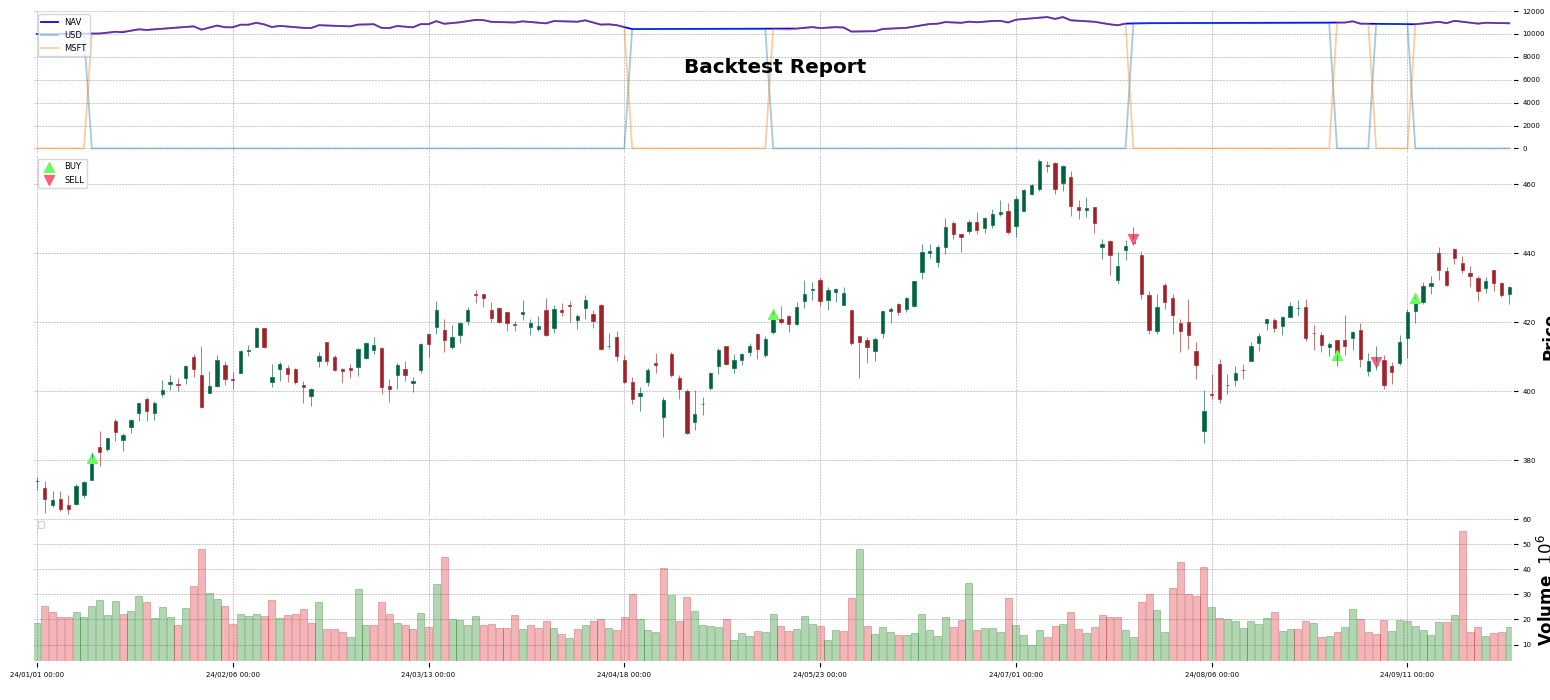

In [ ]:
# pip install ipympl, or use %matplotlib inline 
%matplotlib ipympl
import logging
import tradingbot as tb


class SMACross(tb.Strategy):
    param = {"ticker": "USD/MSFT", "fast": 10, "slow": 20}  # default strategy param

    def start(self):  # function to be called at the startup
        self.logger = logging.getLogger(__name__)
        self.logger.info(f"{self.__class__.__name__} started with param: {self.param}")

    @tb.schedule([tb.trigger.StrategyFirstRun(), tb.trigger.StandardInterval("1d")])  # when to trigger the function
    def next(self, context: dict) -> tb.Order | list[tb.Order] | None:  # function to be called when triggered
        """
        Args:
            context (dict):
                "now": pd.Timestamp, current time
                "trigger": list[Trigger], reason of this run
                "open_order": list[Order], any open orders
        """
        close = self.data["candlestick_1d"]["close"]  # get access to subscribed data from self.data['key']['field']
        ticker, pfast, pslow = self.param["ticker"], self.param["fast"], self.param["slow"]  # get access to parameters from self.param

        # use your favorable way to compute indicators from a pd.Series
        self.sma_fast = close.rolling(window=pfast).mean()  
        self.sma_slow = close.rolling(window=pslow).mean()
        crossup = self.sma_fast.iloc[-2] < self.sma_slow.iloc[-2] and self.sma_fast.iloc[-1] >= self.sma_slow.iloc[-1]
        crossdown = self.sma_fast.iloc[-2] > self.sma_slow.iloc[-2] and self.sma_fast.iloc[-1] <= self.sma_slow.iloc[-1]
        curr_prc = close.iloc[-1]

        if crossup:
            self.logger.info(f"SMA crossed up, buy at {curr_prc:.2f} 🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢")
            order = tb.Order(action="BUY", ticker=ticker, size_type="PCTG", size=1.0, type="MARKET")  # create an all-in market order
        elif crossdown:
            self.logger.info(f"SMA crossed down, sell at {curr_prc:.2f} 🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴")
            order = tb.Order(action="SELL", ticker=ticker, size_type="PCTG", size=1.0, type="MARKET")
        else:
            order = None

        return order

    def stop(self):  # function to be called in the end
        self.logger.info(f"{self.__class__.__name__} stopped")


# fmt: off
bot = tb.Bot( # init a bot
    mode="backtest",  # or "live"
    start="2024-01-01", end="2024-10-01",  # for backtest mode only
)
bot.data = { # subscribe to data 
    # subscribe to USD/MSFT 1d OHLCV from yahoo finance
    "candlestick_1d": tb.data.Candlestick("yahoo", ticker="USD/MSFT", freq="1d", load_len=35)
}
bot.strategy = SMACross(ticker="USD/MSFT", fast=10, slow=30)  # define strategy with param
bot.exchange = tb.exchange.FakeSpotExchange(commission=0.001)  # plug in exchange
bot.account = {"USD": 10_000}  # init from cash
bot.run(plot=True)  # run the bot